In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../data/heart.csv')

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.shape

(918, 12)

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
print(f'Zero values in Cholesterol:', (df['Cholesterol']==0).sum())
print(f'Zero values in RestingBP:', (df['RestingBP']==0).sum())

Zero values in Cholesterol: 172
Zero values in RestingBP: 1


In [10]:
df.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x==0).sum())

HeartDisease
0     20
1    152
Name: Cholesterol, dtype: int64

In [11]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [12]:
print(f'missing % in Heartdisease = 1: is {152/508*100:.1f}%')
print(f'missing % in Heartdisease = 0: is {20/410*100:.1f}%')

missing % in Heartdisease = 1: is 29.9%
missing % in Heartdisease = 0: is 4.9%


In [13]:
df['Cholesterol_missing'] = (df['Cholesterol']== 0).astype(int)

# Cholesterol=0 is medically impossible and represents disguised missing data.
# We flag it before imputing because missingness itself correlates strongly 
# with HeartDisease (88% of missing values belong to positive cases) — 
# this signal would be lost if we imputed silently.

In [14]:
df['Cholesterol_missing'].value_counts()

Cholesterol_missing
0    746
1    172
Name: count, dtype: int64

### We will be doing Group-based imputation	Here:

Which Means Replacing 0 with median cholesterol within similar patients (e.g., grouped by age range or HeartDisease status)

In [15]:
median_Cholesterol = df.loc[df['Cholesterol']!=0, 'Cholesterol'].median()
print(f'Median_cholesterol (Valid reading only): {median_Cholesterol}')

df['Cholesterol'] = df['Cholesterol'].replace(0, median_Cholesterol)

Median_cholesterol (Valid reading only): 237.0


In [16]:
#To Verify no more zeros exist
print('Remaining Zero Values:', (df['Cholesterol'] == 0).sum())

Remaining Zero Values: 0


In [17]:
median_bp = df.loc[df['RestingBP'] != 0, 'RestingBP'].median()
df['RestingBp'] = df['RestingBP'].replace(0, 'median_bp')

## 1.2 Visualizing the Data

**What we want to do here is that:**
Before building any model, we need to understand the shape of our target 
variable and how our features relate to it. This step helps us form 
early intuitions about what the model might learn, and helps us catch 
any surprises in the data before we commit to a modeling approach.

**Class Distribution**

Since this is a binary classification problem, the first thing we check 
is how balanced our two classes are — patients with heart disease (1) 
vs. patients without (0).

**Why this matters:** If one class dominates (e.g., 95% healthy, 5% sick), 
accuracy alone becomes a misleading metric — a model could achieve 95% 
accuracy by just always predicting "healthy" without learning anything 
useful. Understanding this now shapes how we evaluate our model later.

In [18]:
# Checking the exact proportion of each class (0 = No Disease, 1 = Has Disease)
df['HeartDisease'].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

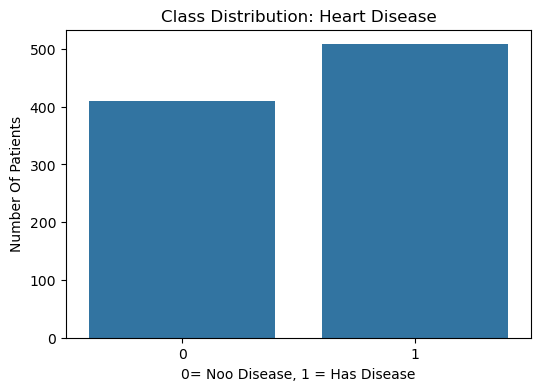

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df,  x = "HeartDisease")
plt.title("Class Distribution: Heart Disease")
plt.xlabel('0= Noo Disease, 1 = Has Disease')
plt.ylabel("Number Of Patients")
plt.show()

### Feature Relationships with the Target

Now that we understand the class balance, we look at how individual 
features differ between patients with and without heart disease. 

**Why this matters:** If a feature shows a clear visual separation 
between the two classes, it's likely to be a strong predictor. If a 
feature looks nearly identical across both classes, it may contribute 
little to the model. This isn't a final decision on feature importance — 
that comes later, mathematically — but it builds early intuition and 
helps us sanity-check the model's behavior afterward.

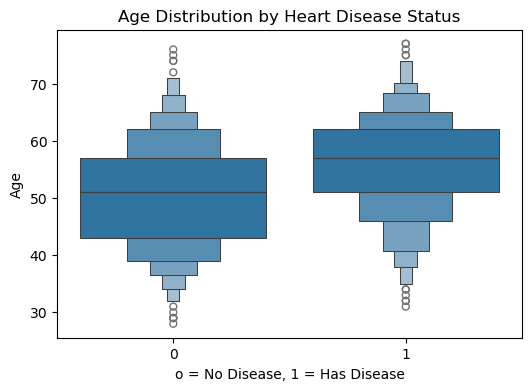

In [20]:
# Compare the distribution of Age between patients with and without heart disease.
# A boxplot lets us see the median, spread, and outliers for each group side by side.
plt.figure(figsize=(6,4))
sns.boxenplot(data=df, x="HeartDisease", y="Age")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("o = No Disease, 1 = Has Disease")
plt.ylabel("Age")
plt.show()

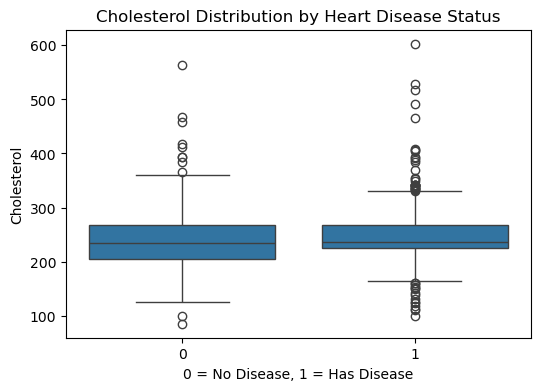

In [21]:
# Same comparison, but for Cholesterol.
# Note: we already cleaned this column earlier, so this reflects the 
# imputed (not raw/disguised-zero) values.
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HeartDisease", y="Cholesterol")
plt.title("Cholesterol Distribution by Heart Disease Status")
plt.xlabel("0 = No Disease, 1 = Has Disease")
plt.ylabel("Cholesterol")
plt.show()

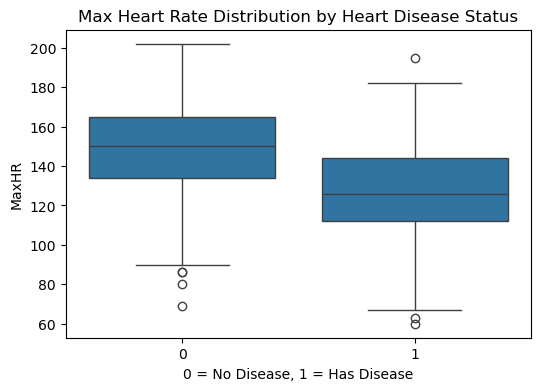

In [22]:
# Same comparison, but for MaxHR (maximum heart rate achieved during exercise test).
# Lower max heart rate is often clinically associated with heart disease,
# so we're checking if that pattern shows up visually in this dataset.
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='HeartDisease', y='MaxHR')
plt.title('Max Heart Rate Distribution by Heart Disease Status')
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.ylabel('MaxHR')
plt.show()

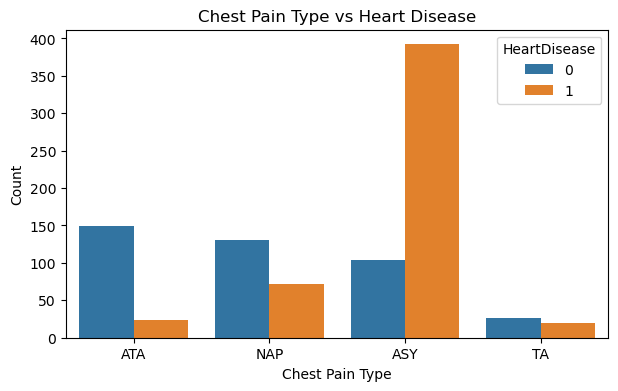

In [23]:
# Compare heart disease rate across categories of ChestPainType.
# We use a countplot with 'hue' to split each category by HeartDisease status,
# showing whether certain chest pain types are more associated with disease.
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease')
plt.title('Chest Pain Type vs Heart Disease')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

**ASY (Asymptomatic) patients are almost 4x more likely to have heart disease than not.**

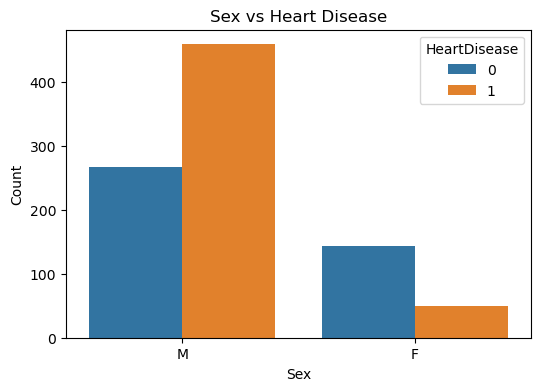

In [24]:
# Same comparison, but for Sex.
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sex', hue='HeartDisease')
plt.title('Sex vs Heart Disease')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

**Male patients in this dataset are considerably more likely to have heart disease, while female patients are considerably more likely to NOT have it.**

In [25]:
df['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

**This dataset shows that it's heavily skewed toward male patients — roughly 4x more men than women.**

The model will see far more examples of male patients, in far more varied situations, than female patients. This means whatever pattern it learns about "Sex" is disproportionately driven by data from men.

**This is called a subgroup performance gap**

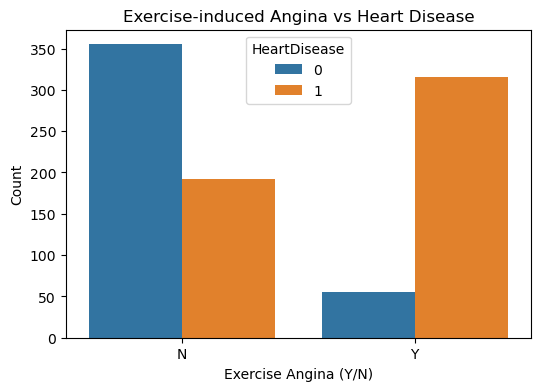

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ExerciseAngina', hue='HeartDisease')
plt.title("Exercise-induced Angina vs Heart Disease")
plt.xlabel('Exercise Angina (Y/N)')
plt.ylabel('Count')
plt.show() 

**This shows Patients without exercise-induced angina mostly don't have heart disease, while patients with exercise-induced angina overwhelmingly do (roughly 6x more likely).**

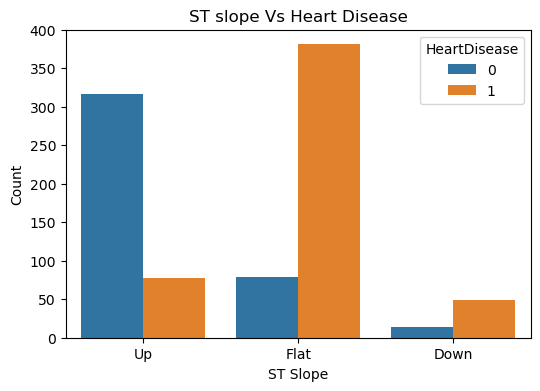

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ST_Slope', hue='HeartDisease')
plt.title('ST slope Vs Heart Disease')
plt.xlabel('ST Slope')
plt.ylabel('Count')
plt.show()

**This also show that patients with a flat ST slope are roughly 5x more likely to have heart disease**